In [5]:
import torch.nn as nn

#==========Model Class===========
#==========Model Class===========
#==========Model Class===========
class FlowPredictor(nn.Module):
    def __init__(self, hidden_dim, output_dim, dropout, input_dim=1):
        super(FlowPredictor, self).__init__()
        #Layer1
        self.lstm1 = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        
        #Layer2
        self.lstm2 = nn.LSTM(hidden_dim, hidden_dim // 2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        
        #Layer3
        self.lstm3 = nn.LSTM(hidden_dim // 2, hidden_dim // 4, batch_first=True)
        self.dropout3 = nn.Dropout(dropout)

        #Last layer
        self.fc = nn.Linear(hidden_dim // 4, output_dim)
        #self.fc = nn.Linear(hidden_dim // 2, output_dim)

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        lstm1_out, _ = self.lstm1(x)
        out = self.dropout1(lstm1_out)

        lstm2_out, _ = self.lstm2(lstm1_out)
        out = self.dropout2(lstm2_out)

        lstm3_out, _ = self.lstm3(lstm2_out)

        # Use the last hidden state for prediction
        last_hidden = lstm3_out[:, -1, :]
        out = self.dropout3(last_hidden)
        #last_hidden = lstm2_out[:, -1, :]
        #out = self.dropout2(last_hidden)
        out = self.fc(out)
        return out

In [6]:
import torch
import joblib
import numpy as np
import json
#from flowpredictor import FlowPredictor
from scipy.signal import savgol_filter
#=========Real Service========
#=========Real Service========
#=========Real Service========
class ReservoirInferenceService:
    def __init__(self, reservoir_configs, window_size=180):
        self.window_size = window_size
        
        # reservoir_configs = {'g': {'weights': 'path', 'scaler': 'path'}, 'i': {...}}
        self.models = {}
        self.scalers = {}

        for name, paths in reservoir_configs.items():
            # Load Config (JSON)
            with open(paths['config'], 'r') as f:
                config = json.load(f)

            # Load Scaler
            self.scalers[name] = joblib.load(paths['scaler'])
            
            # Load Model
            model = FlowPredictor(
                hidden_dim=config['units'],
                output_dim=config['forecast_size'],
                dropout=config['dropout']
            )
            model.load_state_dict(torch.load(paths['weights'], map_location=torch.device('cpu')))
            model.eval()
            self.models[name] = model

    def predict(self, reservoir_name, raw_data):
        # 0. Select the correct tools
        model = self.models[reservoir_name]
        scaler = self.scalers[reservoir_name]
        
        # 1. Scale
        n_min = self.window_size #input window size
        filtered_data = savgol_filter(raw_data, window_length=31, polyorder=1)
        scaled_data = scaler.transform(filtered_data.reshape(-1, 1))
        input_tensor = torch.FloatTensor(scaled_data).view(1, n_min, 1)
        
        # 2. Predict
        with torch.no_grad():
            prediction = model(input_tensor)
            
        # 3. Inverse Scale
        return scaler.inverse_transform(prediction.numpy())


In [18]:
#==========Test==========
#==========Test==========
#==========Test==========
import pandas as pd
import matplotlib.pyplot as plt
# Initialize Inference 
configs = {
    "g": {"weights": "../model/g_resv/g_resv_flow_model.pth", 
          "scaler": "../model/g_resv/g_resv_scaler.pkl", 
          "config":"../model/g_resv/g_resv_config.json"}
}

window_size = 180
forecast_size = 15

inference_service = ReservoirInferenceService(configs, window_size)

#==========Data Load===========
resv_flow = pd.read_csv('../data/rawdata/53.csv')
resv_flow.columns = ['id', 'time', 'resv_flow', 'drop']
del resv_flow['id']
del resv_flow['drop']

start = 1439*350 #1439*365+1
interval = window_size + forecast_size
end = start + interval
raw_data = resv_flow[start:end]

input_data = raw_data[:-forecast_size]
input_data = np.array(input_data['resv_flow'])

val_data = raw_data[-forecast_size:]

#time?
time = raw_data['time']
time = pd.to_datetime(time)
raw_data['time'] = time

print(input_data.shape)
print(val_data.shape)

(180,)
(15, 2)


C:\Users\user\AppData\Local\Temp\ipykernel_11848\3517171403.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_data['time'] = time


In [19]:
output = inference_service.predict("g",input_data)
print(output)

[[46.44042  46.371006 46.527443 46.555115 46.55614  46.592255 46.582092
  46.61778  46.48002  46.421265 46.417297 46.309193 46.223476 46.169147
  46.157753]]


c:\Users\user\miniconda3\envs\mypy\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


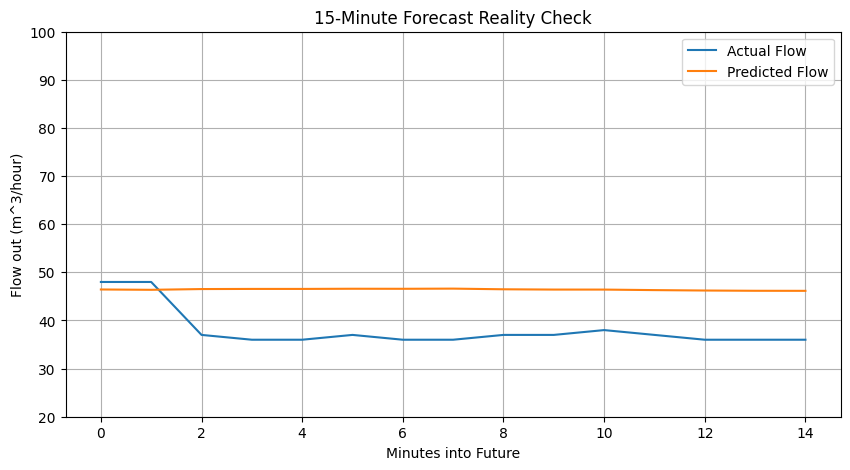

In [20]:
plt.figure(figsize=(10, 5))


plt.plot(range(forecast_size), val_data['resv_flow'].values, label='Actual Flow')#, marker='o')
plt.plot(range(forecast_size), output.reshape(-1,1), label='Predicted Flow')#, marker='x')


plt.title(f"{forecast_size}-Minute Forecast Reality Check")
plt.xlabel("Minutes into Future")
plt.ylabel("Flow out (m^3/hour)")
plt.legend()
plt.grid(True)
plt.ylim(20, 100) 
plt.show()